# 1, reading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

In [2]:
df = pd.read_csv('game_study_data.csv', encoding = 'latin-1')

In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [70]:
df.head()

,S. No.,Timestamp,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GADE,SWL1,SWL2,SWL3,SWL4,SWL5,Game,Platform,Hours,earnings,whyplay,League,highestleague,streams,SPIN1,SPIN2,SPIN3,SPIN4,SPIN5,SPIN6,SPIN7,SPIN8,SPIN9,SPIN10,SPIN11,SPIN12,SPIN13,SPIN14,SPIN15,SPIN16,SPIN17,Narcissism,Gender,Age,Work,Degree,Birthplace,Residence,Reference,Playstyle,accept,GAD_T,SWL_T,SPIN_T,Residence_ISO3,Birthplace_ISO3
0,1,42052.00437,0,0,0,0,1,0,0,Not difficult at all,3,5,5,5,5,Skyrim,"Console (PS, Xbox, ...)",15.0,I play for fun,having fun,NaN,NaN,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,Male,25,Unemployed / between jobs,Bachelor (or equivalent),USA,USA,Reddit,Singleplayer,Accept,1,23,5.0,USA,USA
1,2,42052.00680,1,2,2,2,0,1,0,Somewhat difficult,3,5,2,5,1,Other,PC,8.0,I play for fun,having fun,NaN,NaN,2.0,2.0,1.0,1.0,3.0,2.0,3.0,1.0,3.0,4.0,0.0,3.0,0.0,1.0,3.0,3.0,1.0,2.0,1.0,Male,41,Unemployed / between jobs,Bachelor (or equivalent),USA,USA,Reddit,Multiplayer - online - with strangers,Accept,8,16,33.0,USA,USA
2,3,42052.03860,0,2,2,0,0,3,1,Not difficult at all,2,6,5,2,2,Other,PC,0.0,I play for fun,having fun,NaN,NaN,0.0,1.0,0.0,1.0,2.0,3.0,4.0,2.0,1.0,0.0,1.0,1.0,3.0,0.0,2.0,4.0,4.0,2.0,4.0,Female,32,Employed,Bachelor (or equivalent),Germany,Germany,Reddit,Singleplayer,Accept,8,17,31.0,DEU,DEU
3,4,42052.06804,0,0,0,0,0,0,0,Not difficult at all,2,5,5,3,2,Other,PC,20.0,I play for fun,improving,NaN,NaN,5.0,2.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,1.0,0.0,0.0,2.0,Male,28,Employed,Bachelor (or equivalent),USA,USA,Reddit,Multiplayer - online - with online acquaintanc...,Accept,0,17,11.0,USA,USA
4,5,42052.08948,2,1,2,2,2,3,2,Very difficult,2,2,4,5,1,Other,"Console (PS, Xbox, ...)",20.0,I play for fun,having fun,NaN,NaN,1.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,4.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,3.0,0.0,1.0,Male,19,Employed,High school diploma (or equivalent),USA,South Korea,Reddit,Multiplayer - online - with strangers,Accept,14,14,13.0,KOR,USA


# 2, data cleaning

In [4]:
df.shape

(13464, 55)

In [9]:
sub2.isna().sum()

Timestamp     0
GAD1          0
GAD2          0
GAD3          0
GAD4          0
GAD5          0
GAD6          0
GAD7          0
GADE          0
SWL1          0
SWL2          0
SWL3          0
SWL4          0
SWL5          0
Game          0
Platform      0
Hours         0
streams       0
SPIN1         0
SPIN2         0
SPIN3         0
SPIN4         0
SPIN5         0
SPIN6         0
SPIN7         0
SPIN8         0
SPIN9         0
SPIN10        0
SPIN11        0
SPIN12        0
SPIN13        0
SPIN14        0
SPIN15        0
SPIN16        0
SPIN17        0
Narcissism    0
Gender        0
Age           0
Work          0
Degree        0
GAD_T         0
SWL_T         0
SPIN_T        0
dtype: int64

In [12]:
sub2.dtypes

Timestamp     float64
GAD1            int64
GAD2            int64
GAD3            int64
GAD4            int64
GAD5            int64
GAD6            int64
GAD7            int64
GADE             int8
SWL1            int64
SWL2            int64
SWL3            int64
SWL4            int64
SWL5            int64
Game             int8
Platform         int8
Hours         float64
streams       float64
SPIN1         float64
SPIN2         float64
SPIN3         float64
SPIN4         float64
SPIN5         float64
SPIN6         float64
SPIN7         float64
SPIN8         float64
SPIN9         float64
SPIN10        float64
SPIN11        float64
SPIN12        float64
SPIN13        float64
SPIN14        float64
SPIN15        float64
SPIN16        float64
SPIN17        float64
Narcissism    float64
Gender           int8
Age             int64
Work             int8
Degree           int8
GAD_T           int64
SWL_T           int64
SPIN_T        float64
dtype: object

In [63]:
sub2['Degree'].unique()

array(['Bachelor\xa0(or equivalent)',
       'High school diploma (or equivalent)',
       'Ph.D., Psy. D., MD (or equivalent)', 'Master\xa0(or equivalent)'],
      dtype=object)

In [4]:
sub1 = df.drop(['S. No.','earnings','whyplay','League','highestleague', 'Birthplace', 'Residence', 'Reference', 'Playstyle', 'accept', 'Residence_ISO3', 'Birthplace_ISO3'], axis = 1)

In [5]:
sub2 = sub1.dropna()

In [6]:
sub2.shape

(10653, 43)

In [10]:
sub2['GADE'] = pd.Categorical(sub2['GADE'], categories= ['Not difficult at all', 'Somewhat difficult', 'Very difficult',
       'Extremely difficult'], ordered = True)
sub2['Game'] = pd.Categorical(sub2['Game'], categories= ['Skyrim', 'Other', 'World of Warcraft', 'Starcraft 2',
       'League of Legends', 'Counter Strike', 'Destiny', 'Diablo 3',
       'Heroes of the Storm', 'Hearthstone', 'Guild Wars 2'], ordered = True)
sub2['Platform'] = pd.Categorical(sub2['Platform'], categories= ['Console (PS, Xbox, ...)', 'PC', 'Smartphone / Tablet'], ordered = True)
sub2['Gender'] = pd.Categorical(sub2['Gender'], categories= ['Male', 'Female', 'Other'], ordered = True)
sub2['Work'] = pd.Categorical(sub2['Work'], categories= ['Unemployed / between jobs', 'Employed',
       'Student at college / university', 'Student at school'], ordered = True)
sub2['Degree'] = pd.Categorical(sub2['Degree'], categories= [r'Bachelor\xa0(or equivalent)',
       'High school diploma (or equivalent)',
       'Ph.D., Psy. D., MD (or equivalent)', r'Master\xa0(or equivalent)'], ordered = True)

/tmp/ipykernel_19473/4049666530.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub2['GADE'] = pd.Categorical(sub2['GADE'], categories= ['Not difficult at all', 'Somewhat difficult', 'Very difficult',
/tmp/ipykernel_19473/4049666530.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub2['Game'] = pd.Categorical(sub2['Game'], categories= ['Skyrim', 'Other', 'World of Warcraft', 'Starcraft 2',
/tmp/ipykernel_19473/4049666530.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice

In [11]:
sub2['GADE'] = sub2['GADE'].cat.codes
sub2['Game'] = sub2['Game'].cat.codes
sub2['Platform'] = sub2['Platform'].cat.codes
sub2['Gender'] = sub2['Gender'].cat.codes
sub2['Work'] = sub2['Work'].cat.codes
sub2['Degree'] = sub2['Degree'].cat.codes

/tmp/ipykernel_19473/3358038179.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub2['GADE'] = sub2['GADE'].cat.codes
/tmp/ipykernel_19473/3358038179.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub2['Game'] = sub2['Game'].cat.codes
/tmp/ipykernel_19473/3358038179.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stabl

In [13]:
sub2.to_csv('cleaned_data/cleaned_game_study_data.csv', index = False)

In [2]:
data = pd.read_csv('cleaned_data/cleaned_game_study_data.csv')

In [15]:
data.head()

,Timestamp,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GADE,SWL1,SWL2,SWL3,SWL4,SWL5,Game,Platform,Hours,streams,SPIN1,SPIN2,SPIN3,SPIN4,SPIN5,SPIN6,SPIN7,SPIN8,SPIN9,SPIN10,SPIN11,SPIN12,SPIN13,SPIN14,SPIN15,SPIN16,SPIN17,Narcissism,Gender,Age,Work,Degree,GAD_T,SWL_T,SPIN_T
0,42052.00437,0,0,0,0,1,0,0,0,3,5,5,5,5,0,0,15.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0,25,0,-1,1,23,5.0
1,42052.00680,1,2,2,2,0,1,0,1,3,5,2,5,1,1,1,8.0,2.0,2.0,1.0,1.0,3.0,2.0,3.0,1.0,3.0,4.0,0.0,3.0,0.0,1.0,3.0,3.0,1.0,2.0,1.0,0,41,0,-1,8,16,33.0
2,42052.03860,0,2,2,0,0,3,1,0,2,6,5,2,2,1,1,0.0,0.0,1.0,0.0,1.0,2.0,3.0,4.0,2.0,1.0,0.0,1.0,1.0,3.0,0.0,2.0,4.0,4.0,2.0,4.0,1,32,1,-1,8,17,31.0
3,42052.06804,0,0,0,0,0,0,0,0,2,5,5,3,2,1,1,20.0,5.0,2.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,1.0,0.0,0.0,2.0,0,28,1,-1,0,17,11.0
4,42052.08948,2,1,2,2,2,3,2,2,2,2,4,5,1,1,0,20.0,1.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,4.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,3.0,0.0,1.0,0,19,1,1,14,14,13.0


# 3. visuals

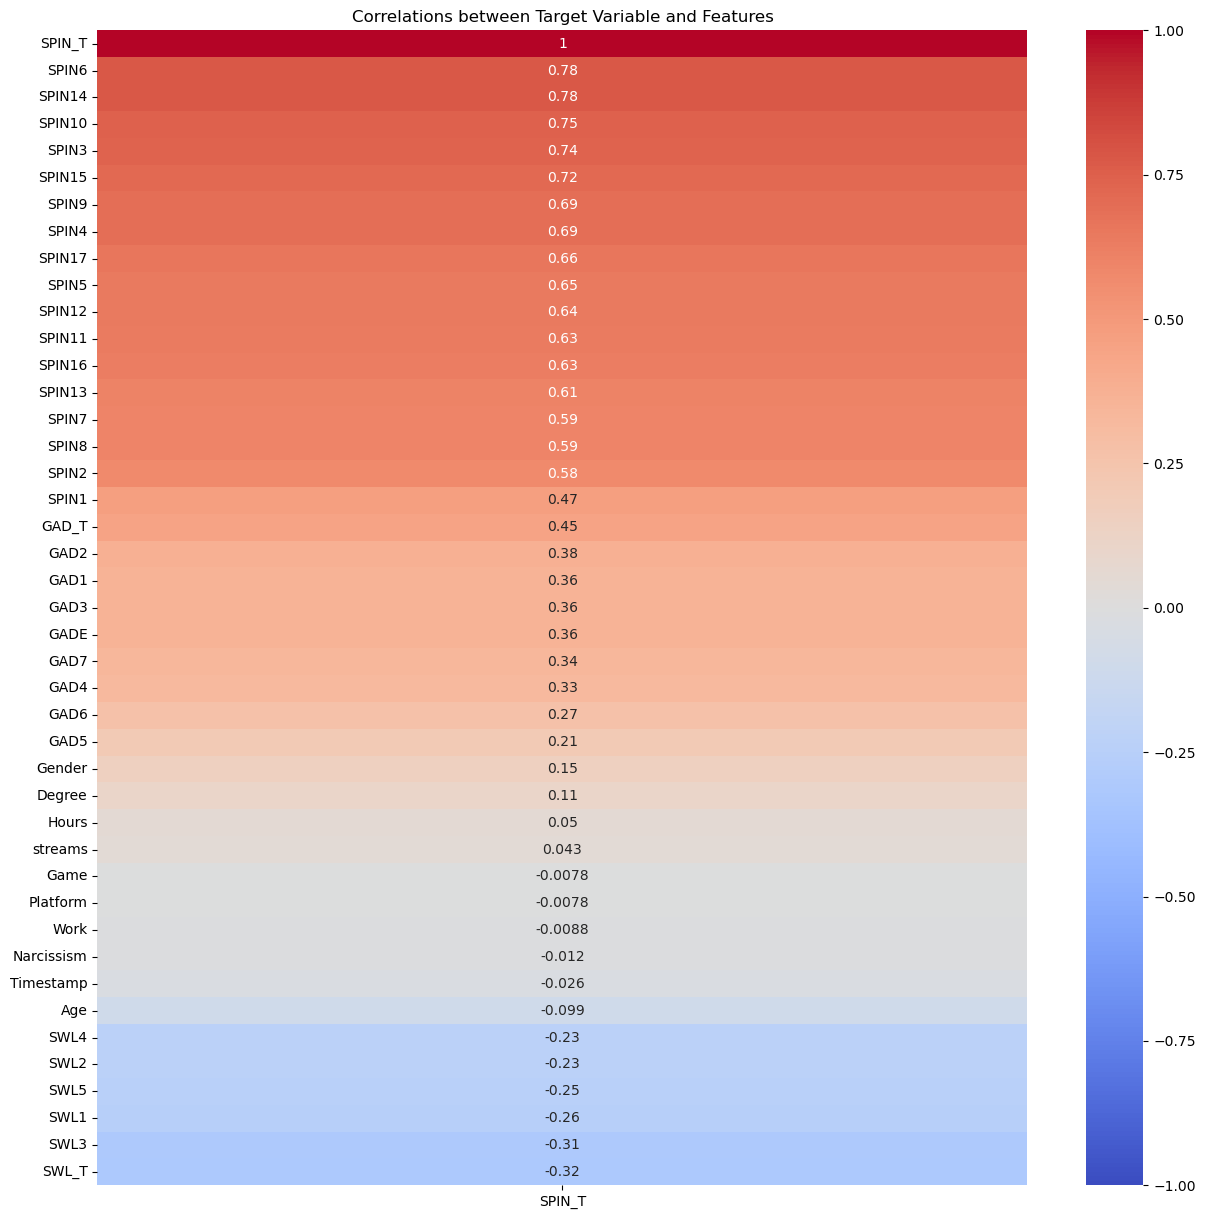

In [3]:
plt.figure(figsize= (15, 15))
sns.heatmap(data.corr()[['SPIN_T']].sort_values(by = 'SPIN_T', ascending = False), 
           vmin = -1, 
           vmax = 1, 
           annot = True, 
           cmap = "coolwarm")
plt.title('Correlations between Target Variable and Features')
plt.savefig('visuals/heatmap.png')

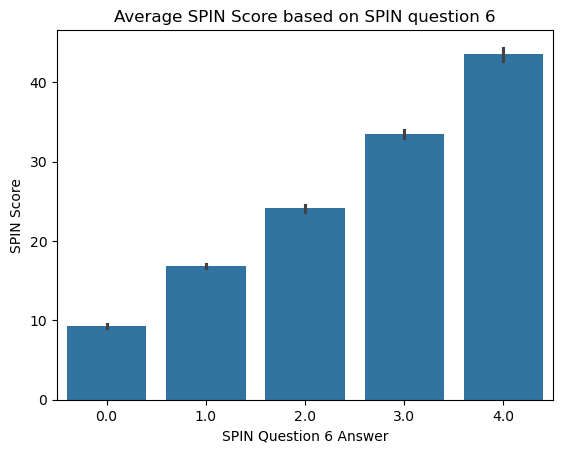

In [4]:
sns.barplot(data, x = 'SPIN6', y = 'SPIN_T')
plt.title('Average SPIN Score based on SPIN question 6')
plt.xlabel('SPIN Question 6 Answer')
plt.ylabel('SPIN Score')
plt.savefig('visuals/barplot1.png')

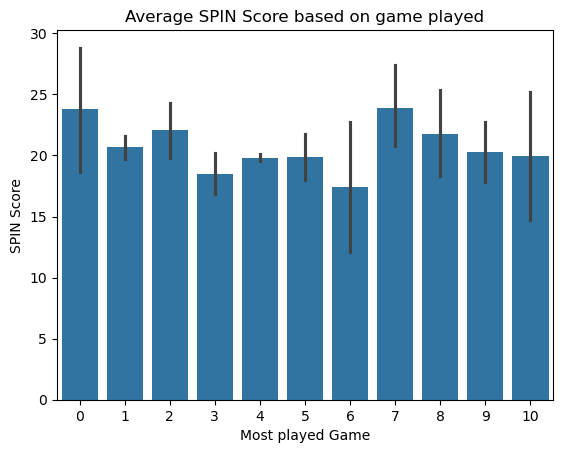

In [5]:
sns.barplot(data, x = 'Game', y = 'SPIN_T')
plt.title('Average SPIN Score based on game played')
plt.xlabel('Most played Game')
plt.ylabel('SPIN Score')
plt.savefig('visuals/barplot2.png')

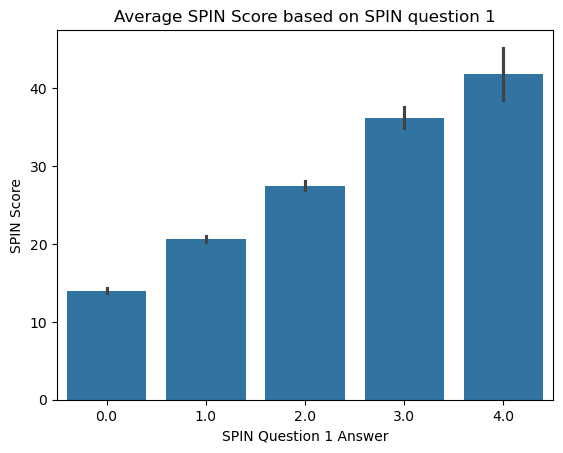

In [6]:
sns.barplot(data, x = 'SPIN1', y = 'SPIN_T')
plt.title('Average SPIN Score based on SPIN question 1')
plt.xlabel('SPIN Question 1 Answer')
plt.ylabel('SPIN Score')
plt.savefig('visuals/barplot3.png')

# 4, Modeling

## Linear Regression

In [14]:
X = data[['SPIN1', 'SPIN2',	'SPIN3','SPIN4','SPIN5','SPIN6','SPIN7','SPIN8','SPIN9','SPIN10','SPIN11','SPIN12','SPIN13','SPIN14','SPIN15','SPIN16','SPIN17']]

y = data['SPIN_T']

In [24]:
X

,SPIN1,SPIN2,SPIN3,SPIN4,SPIN5,SPIN6,SPIN7,SPIN8,SPIN9,SPIN10,SPIN11,SPIN12,SPIN13,SPIN14,SPIN15,SPIN16,SPIN17
0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,2.0,1.0,1.0,3.0,2.0,3.0,1.0,3.0,4.0,0.0,3.0,0.0,1.0,3.0,3.0,1.0,2.0
2,1.0,0.0,1.0,2.0,3.0,4.0,2.0,1.0,0.0,1.0,1.0,3.0,0.0,2.0,4.0,4.0,2.0
3,2.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,1.0,0.0,0.0
4,2.0,0.0,0.0,0.0,1.0,0.0,0.0,4.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10648,1.0,1.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
10649,0.0,1.0,2.0,2.0,0.0,1.0,3.0,3.0,2.0,1.0,4.0,0.0,2.0,2.0,1.0,0.0,1.0
10650,0.0,1.0,0.0,2.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
10651,0.0,1.0,3.0,2.0,3.0,4.0,1.0,3.0,4.0,1.0,3.0,1.0,0.0,3.0,2.0,0.0,1.0


In [25]:
y

0         5.0
1        33.0
2        31.0
3        11.0
4        13.0
         ... 
10648     7.0
10649    25.0
10650    10.0
10651    32.0
10652    14.0
Name: SPIN_T, Length: 10653, dtype: float64

In [15]:
scores = []

for i in range(15, 31, 1):
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size= i/100)
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    lr_train = lr.score(X_train, y_train)
    lr_test = lr.score(X_test, y_test)
    scores.append({'test_size': i, 'train_score': lr_train, 'test_score': lr_test})

lr_scores = pd.DataFrame(scores)

In [16]:
lr_scores

,test_size,train_score,test_score
0,15,1.0,1.0
1,16,1.0,1.0
2,17,1.0,1.0
3,18,1.0,1.0
4,19,1.0,1.0
5,20,1.0,1.0
6,21,1.0,1.0
7,22,1.0,1.0
8,23,1.0,1.0
9,24,1.0,1.0


In [17]:
X = data[['SPIN1', 'SPIN2',	'SPIN3','SPIN4','SPIN5','SPIN6','SPIN7','SPIN8','SPIN9','SPIN10','SPIN11','SPIN12','SPIN13','SPIN14','SPIN15','SPIN16','SPIN17']]

y = data['SPIN_T']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [18]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
lr.score(X_test, y_test)

1.0

In [21]:
y_preds = lr.predict(X_test)
root_mean_squared_error(y_test, y_preds)

5.844175788405075e-14

In [22]:
baseline_preds = np.full_like(y_test, y_test.mean())
root_mean_squared_error(y_test, baseline_preds)

13.464897953580033

In [23]:
mean_absolute_percentage_error(y_test, y_preds)

0.48048048048048375

## For decission tree rregressor

In [27]:
scores = []

for i in range(10, 31, 1):
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = i/100)
    dtr = DecisionTreeRegressor(random_state = 42)
    dtr.fit(X_train, y_train)
    dtr_train = dtr.score(X_train, y_train)
    dtr_test = dtr.score(X_test, y_test)
    scores.append({'test_size': i, 'train_score': dtr_train, 'test_score': dtr_test})

dtr_scores = pd.DataFrame(scores)

In [28]:
dtr_scores

,test_size,train_score,test_score
0,10,1.0,0.904207
1,11,1.0,0.912502
2,12,1.0,0.907179
3,13,1.0,0.905734
4,14,1.0,0.910279
5,15,1.0,0.912805
6,16,1.0,0.906400
7,17,1.0,0.905173
8,18,1.0,0.903550
9,19,1.0,0.905555


In [29]:
X = data[['SPIN1', 'SPIN2',	'SPIN3','SPIN4','SPIN5','SPIN6','SPIN7','SPIN8','SPIN9','SPIN10','SPIN11','SPIN12','SPIN13','SPIN14','SPIN15','SPIN16','SPIN17']]

y = data['SPIN_T']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size= 0.15)

In [30]:
dtr = DecisionTreeRegressor(random_state = 42)

In [31]:
dtr.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [32]:
dtr.score(X_test, y_test)

0.912805401287099

In [33]:
y_preds = dtr.predict(X_test)
root_mean_squared_error(y_test, y_preds)

3.925463230877499

In [34]:
baseline_preds = np.full_like(y_test, y_test.mean())
root_mean_squared_error(y_test, baseline_preds)

13.29370760078915

In [35]:
mean_absolute_percentage_error(y_test, y_preds)

0.1685813101574925

## For random forest

In [37]:
scores = []

for i in range(10, 31, 1):
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = i/100)
    rfr = RandomForestRegressor(random_state= 42)
    rfr.fit(X_train, y_train)
    rfr_train = rfr.score(X_train, y_train)
    rfr_test = rfr.score(X_test, y_test)
    scores.append({'test_size': i, 'train_score': rfr_train, 'test_score': rfr_test})

rfr_scores = pd.DataFrame(scores)

In [38]:
rfr_scores

,test_size,train_score,test_score
0,10,0.996939,0.976486
1,11,0.996928,0.977486
2,12,0.996790,0.977669
3,13,0.996910,0.979243
4,14,0.997027,0.979900
5,15,0.996940,0.977981
6,16,0.996934,0.978733
7,17,0.996950,0.978663
8,18,0.997004,0.978236
9,19,0.997001,0.978602


In [39]:
X = data[['SPIN1', 'SPIN2',	'SPIN3','SPIN4','SPIN5','SPIN6','SPIN7','SPIN8','SPIN9','SPIN10','SPIN11','SPIN12','SPIN13','SPIN14','SPIN15','SPIN16','SPIN17']]

y = data['SPIN_T']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size= 0.14)

In [40]:
rfr = RandomForestRegressor(random_state= 42)

In [41]:
rfr.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
rfr.score(X_test, y_test)

0.9798999483975087

In [43]:
y_preds = rfr.predict(X_test)
root_mean_squared_error(y_test, y_preds)

1.891951912056306

In [44]:
baseline_preds = np.full_like(y_test, y_test.mean())
root_mean_squared_error(y_test, baseline_preds)

13.344782735901966

In [45]:
mean_absolute_percentage_error(y_test, y_preds)

0.07675760292801359

## For KNN

In [46]:
def model_factory(model, columns):
    """
    Creator: Daniel
    inputs: 
        model: The machine learning model object to use in the pipeline
        columns: the list of columns to use for scaling
    outputs:
        returns the model, ready to be fitted and used. 
    """
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), columns)
        ],
        remainder='passthrough'
    )
    # this preprocessor will scale the columns passed in. Any other columns will go through without being scaled. 
    model = Pipeline(
        steps=[
            ('preprocess', preprocessor),
            ('model', model)
        ]
    )
    # this is the pipeline the model will use, so it will first scale it with the preprocessor, then run it through the model. 
    # this will make it easier to use, as it will scale the inputs automatically, so it doesn't need to be scaled
    # outside of the model. 
    return model

# function creates a pipline that automatically scales values for you

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size= 0.15)

In [48]:
scores = []

for k in range(3, 32, 2):
    knn = model_factory(KNeighborsRegressor(n_neighbors = k), X.columns)
    knn.fit(X_train, y_train)
    train_score = knn.score(X_train, y_train)
    test_score = knn.score(X_test, y_test)
    scores.append({'k': k, 'train_score': train_score, 'test_score': test_score})

knn_scores = pd.DataFrame(scores)

In [49]:
knn_scores

,k,train_score,test_score
0,3,0.989605,0.981286
1,5,0.989612,0.984697
2,7,0.989756,0.986797
3,9,0.989902,0.987531
4,11,0.989986,0.988028
5,13,0.989909,0.988268
6,15,0.989829,0.988515
7,17,0.989759,0.988744
8,19,0.989614,0.988804
9,21,0.989547,0.988692


In [53]:
knn = model_factory(KNeighborsRegressor(n_neighbors = 19), X.columns)

In [55]:
knn.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [56]:
knn.score(X_test, y_test)

0.9888037377662687

In [57]:
y_preds = knn.predict(X_test)
root_mean_squared_error(y_test, y_preds)

1.4066389955774075

In [58]:
baseline_preds = np.full_like(y_test, y_test.mean())
root_mean_squared_error(y_test, baseline_preds)

13.29370760078915

In [59]:
mean_absolute_percentage_error(y_test, y_preds)

0.08803420166581054

## Pickling KNN

In [60]:
knn_pkl = ''

In [61]:
with open('knn_pkl', 'wb') as file:
    model = pickle.dump(knn, file)

In [62]:
with open('knn_pkl', 'rb') as file:
    model = pickle.load(file)